In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, log_loss
from scipy.optimize import minimize

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pl.read_csv('../data/train.csv')
test_df = pl.read_csv('../data/test.csv')

print('Train Data Shape:',{train_df.shape})
print('Test Data Shape:',{test_df.shape})

train_df.head()

Train Data Shape: {(630000, 21)}
Test Data Shape: {(270000, 20)}


id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,str,f64,str,str
0,"""Loamy""",4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.9,16.79,"""Sugarcane""","""Sowing""","""Zaid""","""Drip""","""Rainwater""",0.82,"""No""",112.16,"""East""","""Low"""
1,"""Clay""",7.08,56.61,0.44,2.0,22.92,67.86,985.66,6.98,3.39,"""Wheat""","""Vegetative""","""Kharif""","""Rainfed""","""River""",5.27,"""Yes""",47.16,"""South""","""Low"""
2,"""Clay""",5.69,27.71,0.81,2.83,26.97,92.22,2201.7,6.05,3.85,"""Rice""","""Vegetative""","""Kharif""","""Sprinkler""","""Reservoir""",8.24,"""Yes""",110.38,"""North""","""Low"""
3,"""Sandy""",5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,"""Wheat""","""Flowering""","""Kharif""","""Canal""","""River""",8.32,"""Yes""",53.85,"""South""","""Medium"""
4,"""Clay""",7.96,59.14,0.38,0.96,20.22,91.11,1538.2,6.95,13.94,"""Wheat""","""Sowing""","""Rabi""","""Canal""","""River""",7.37,"""No""",93.19,"""South""","""Low"""


In [3]:
# Data Types and Null Values
print(train_df.schema)

# Null Values Check
print(train_df.null_count())

# Statistics
train_df.describe()

Schema({'id': Int64, 'Soil_Type': String, 'Soil_pH': Float64, 'Soil_Moisture': Float64, 'Organic_Carbon': Float64, 'Electrical_Conductivity': Float64, 'Temperature_C': Float64, 'Humidity': Float64, 'Rainfall_mm': Float64, 'Sunlight_Hours': Float64, 'Wind_Speed_kmh': Float64, 'Crop_Type': String, 'Crop_Growth_Stage': String, 'Season': String, 'Irrigation_Type': String, 'Water_Source': String, 'Field_Area_hectare': Float64, 'Mulching_Used': String, 'Previous_Irrigation_mm': Float64, 'Region': String, 'Irrigation_Need': String})
shape: (1, 21)
┌─────┬───────────┬─────────┬──────────────┬───┬──────────────┬─────────────┬────────┬─────────────┐
│ id  ┆ Soil_Type ┆ Soil_pH ┆ Soil_Moistur ┆ … ┆ Mulching_Use ┆ Previous_Ir ┆ Region ┆ Irrigation_ │
│ --- ┆ ---       ┆ ---     ┆ e            ┆   ┆ d            ┆ rigation_mm ┆ ---    ┆ Need        │
│ u32 ┆ u32       ┆ u32     ┆ ---          ┆   ┆ ---          ┆ ---         ┆ u32    ┆ ---         │
│     ┆           ┆         ┆ u32          ┆   ┆ 

statistic,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,str,f64,str,str
"""count""",630000.0,"""630000""",630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,630000.0,"""630000""","""630000""","""630000""","""630000""","""630000""",630000.0,"""630000""",630000.0,"""630000""","""630000"""
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""0""","""0"""
"""mean""",314999.5,null,6.482497,37.304482,0.922858,1.744605,26.998166,61.56318,1462.207566,7.513382,10.375394,null,null,null,null,null,7.517745,null,62.318177,null,null
"""std""",181865.479132,null,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,null,null,null,null,null,4.218124,null,34.246939,null,null
"""min""",0.0,"""Clay""",4.8,8.0,0.3,0.1,12.0,25.0,0.38,4.0,0.5,"""Cotton""","""Flowering""","""Kharif""","""Canal""","""Groundwater""",0.3,"""No""",0.02,"""Central""","""High"""
"""25%""",157500.0,null,5.69,23.34,0.61,0.93,19.52,45.39,954.57,5.76,5.28,null,null,null,null,null,3.88,null,33.14,null,null
"""50%""",315000.0,null,6.44,37.75,0.91,1.74,26.96,61.65,1467.24,7.58,10.48,null,null,null,null,null,7.38,null,61.15,null,null
"""75%""",472499.0,null,7.27,51.27,1.22,2.58,34.54,79.12,2054.28,9.25,15.43,null,null,null,null,null,11.14,null,92.69,null,null
"""max""",629999.0,"""Silt""",8.2,64.99,1.6,3.5,42.0,94.99,2499.69,11.0,20.0,"""Wheat""","""Vegetative""","""Zaid""","""Sprinkler""","""River""",15.0,"""Yes""",119.99,"""West""","""Medium"""


# EDA

shape: (3, 3)
┌─────────────────┬────────┬───────┐
│ Irrigation_Need ┆ count  ┆ pct   │
│ ---             ┆ ---    ┆ ---   │
│ str             ┆ u32    ┆ f64   │
╞═════════════════╪════════╪═══════╡
│ Low             ┆ 369917 ┆ 58.72 │
│ Medium          ┆ 239074 ┆ 37.95 │
│ High            ┆ 21009  ┆ 3.33  │
└─────────────────┴────────┴───────┘


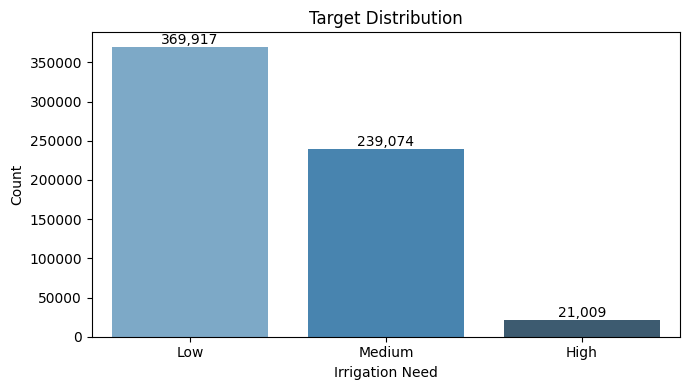

In [4]:
# Target Distribution
TARGET = 'Irrigation_Need'

target_counts = (
    train_df
    .group_by(TARGET)
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / pl.col('count').sum() * 100).round(2).alias('pct'))
    .sort('count', descending=True)
)
print(target_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=target_counts.to_pandas(),
    x=TARGET, y='count',
    order=target_counts[TARGET].to_list(),
    palette='Blues_d', ax=ax
)
ax.set_title('Target Distribution')
ax.set_xlabel('Irrigation Need')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

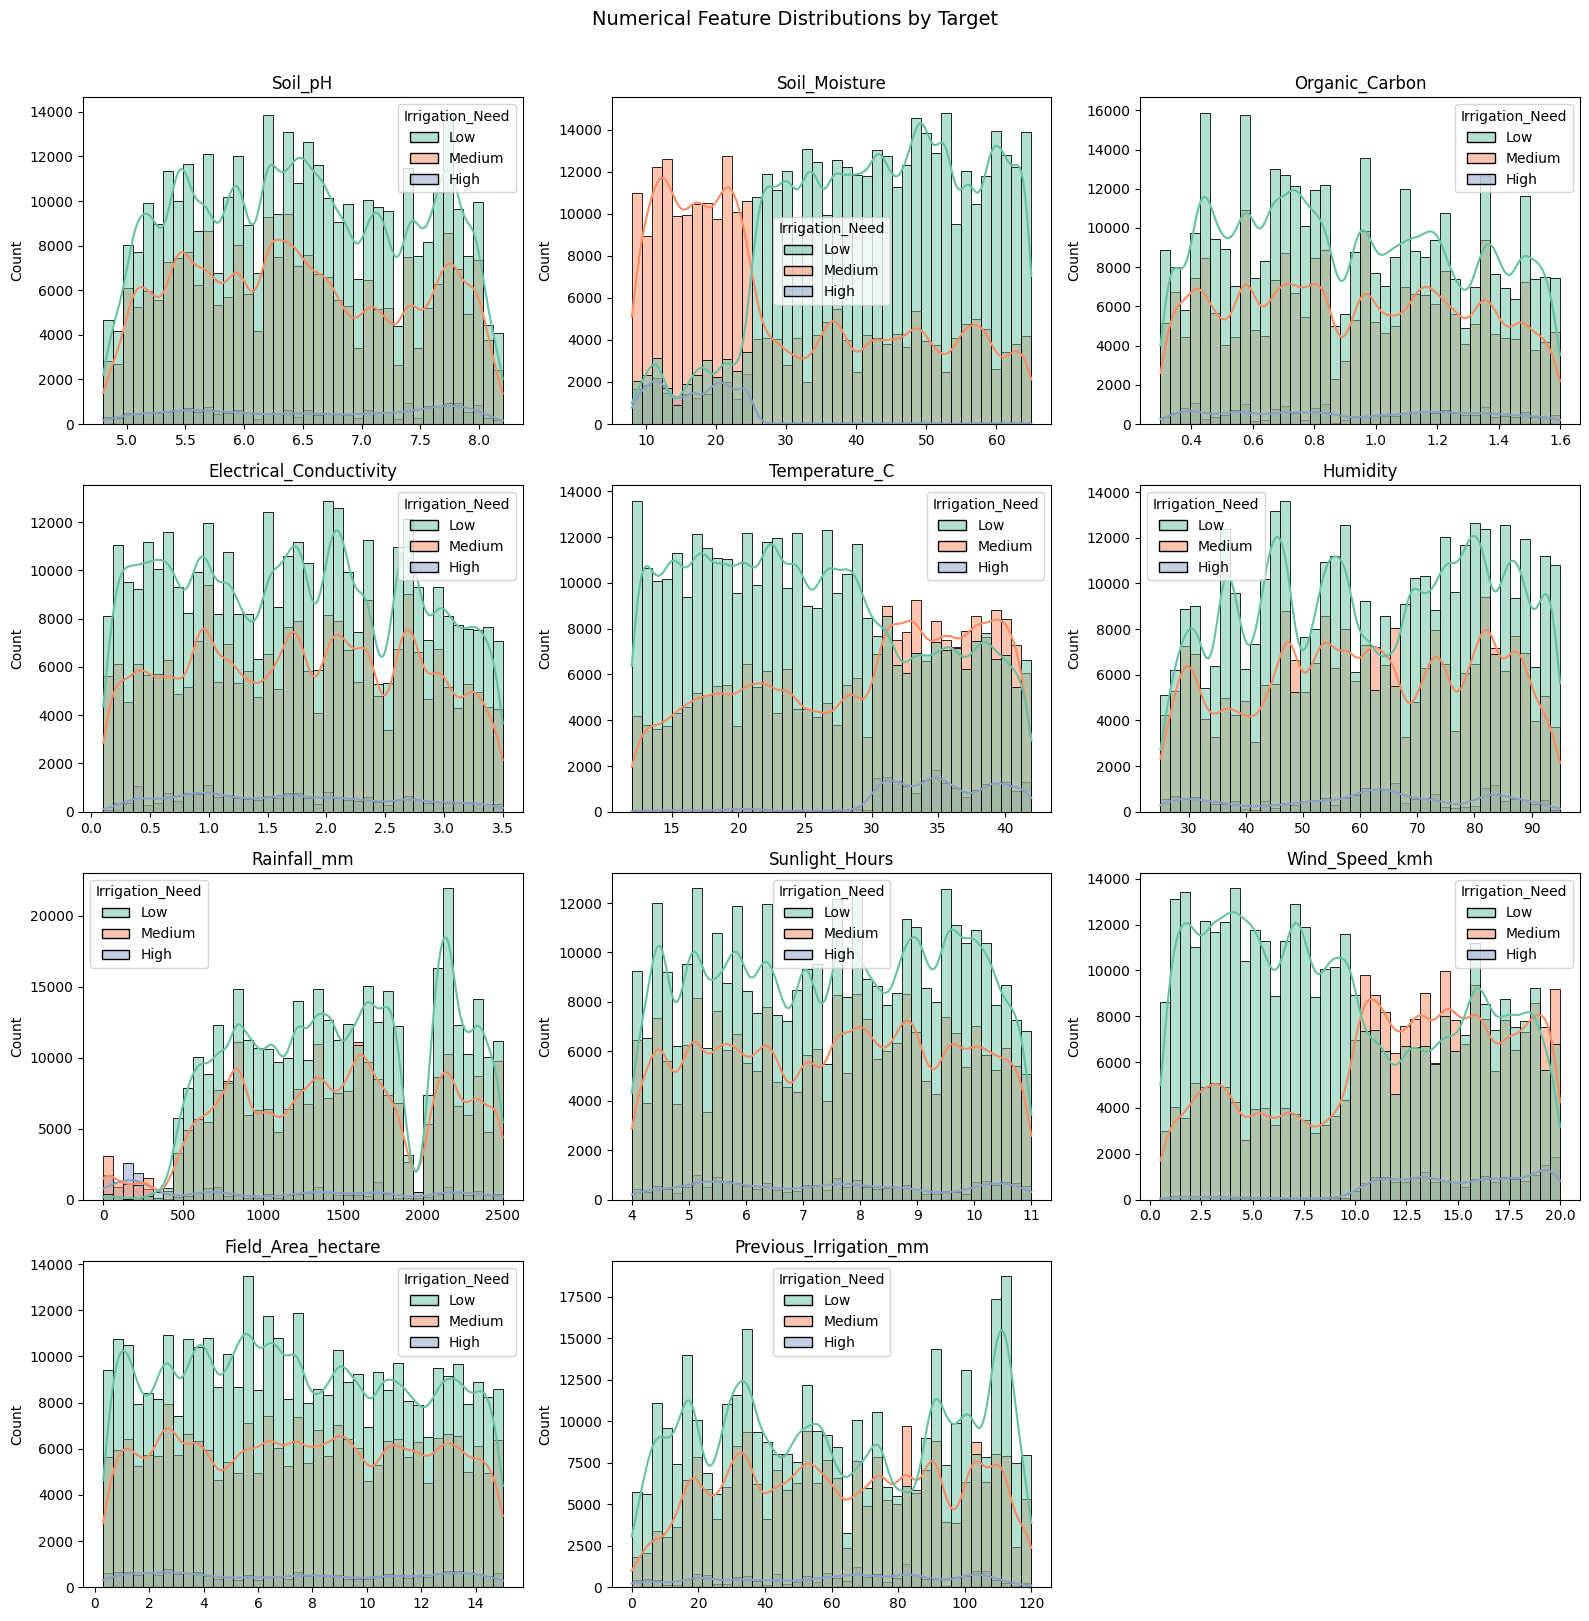

In [5]:
# Numerical Feature Distribution
NUM_COLS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'
]

train_pd = train_df.to_pandas()

n_cols = 3
n_rows = (len(NUM_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.histplot(
        data=train_pd, x=col, hue=TARGET,
        kde=True, bins=40, ax=axes[i], palette='Set2'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


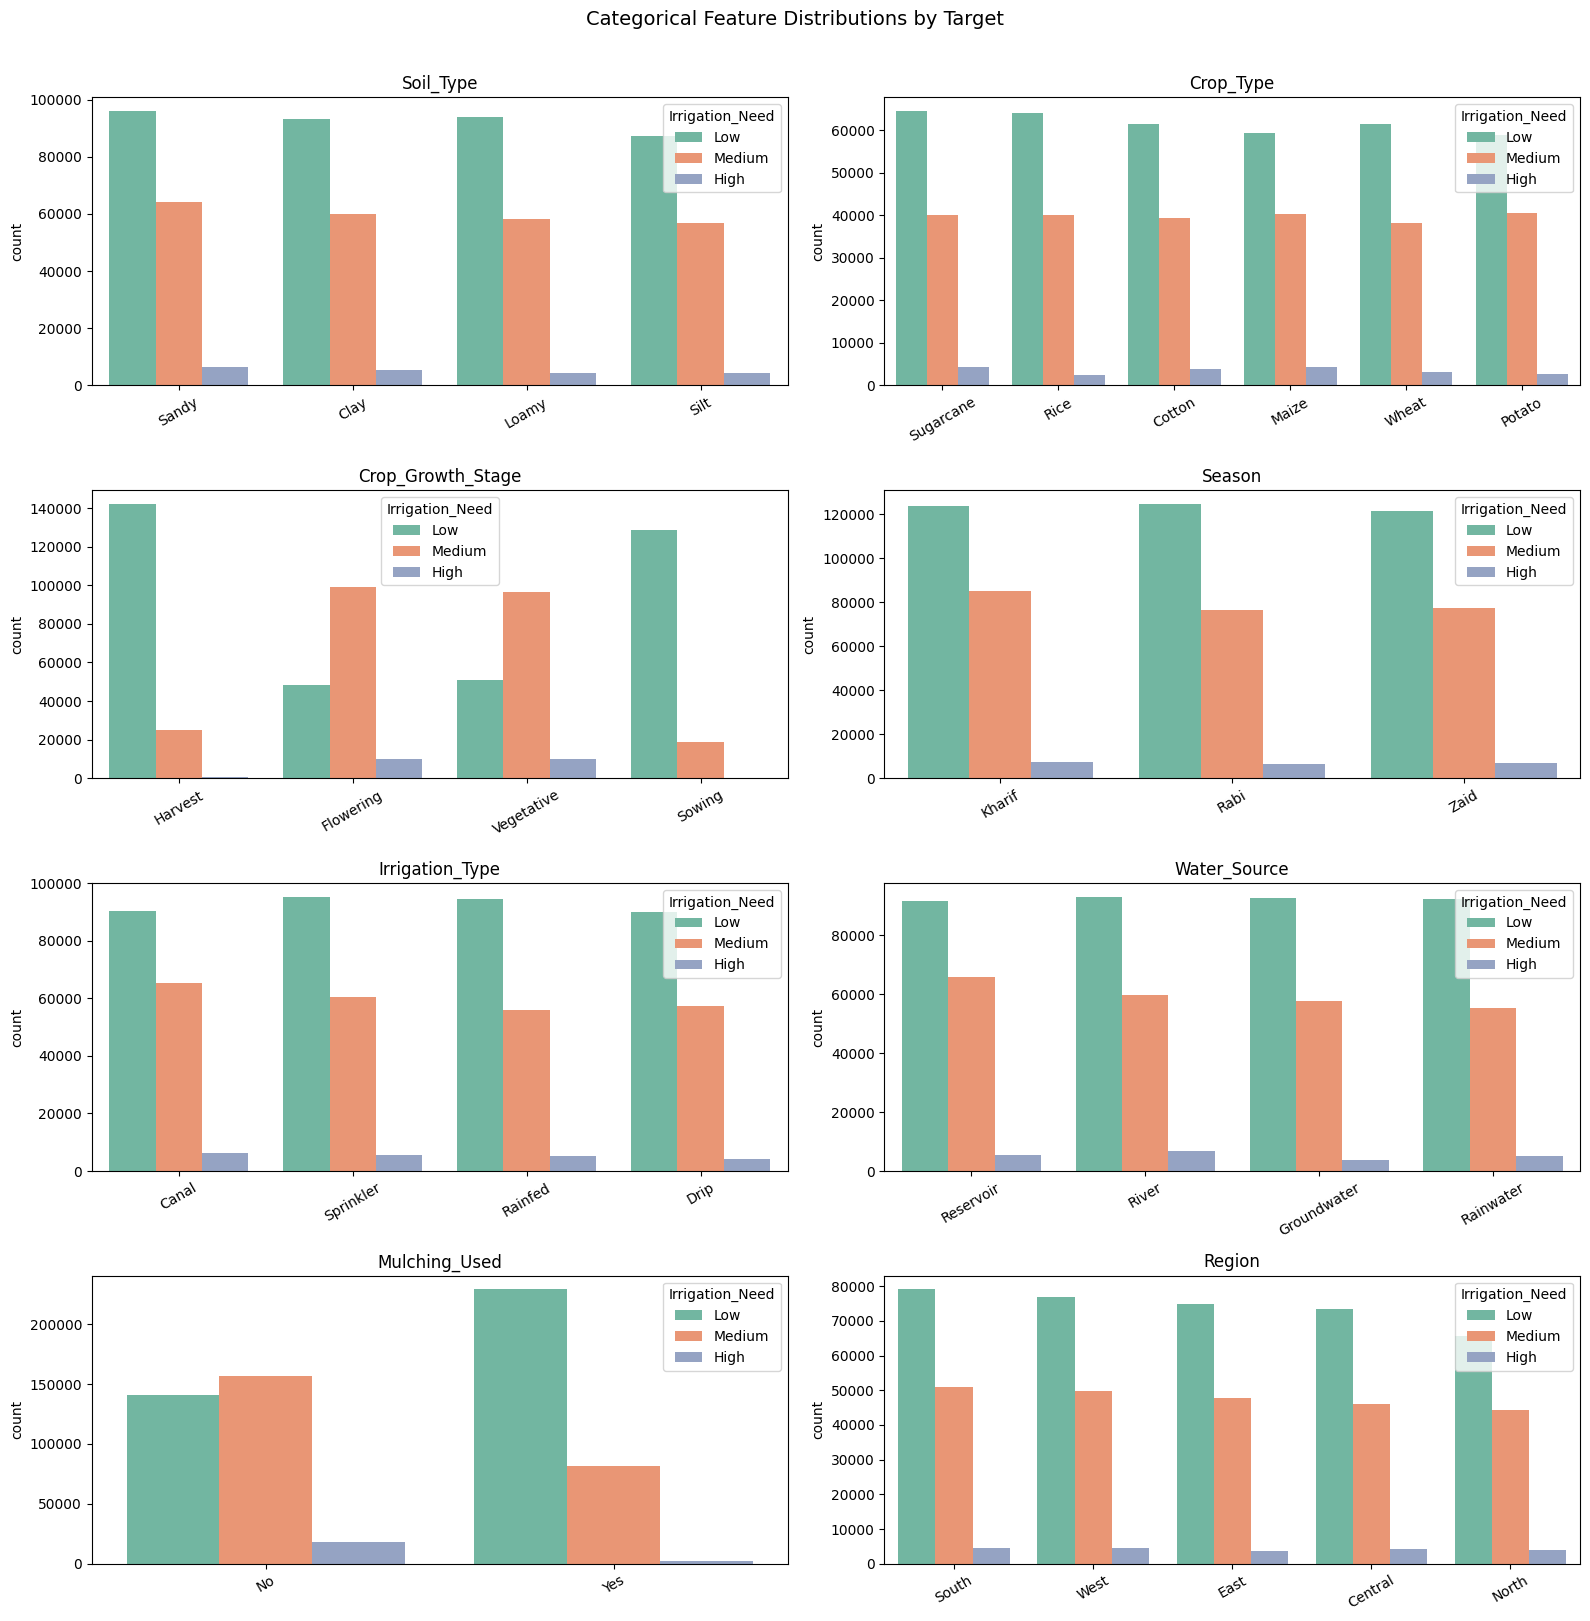

In [6]:
# Categorical Feature Distribution
CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region'
]

n_cols = 2
n_rows = (len(CAT_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    order = train_pd[col].value_counts().index.tolist()
    sns.countplot(
        data=train_pd, x=col, hue=TARGET,
        order=order, palette='Set2', ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

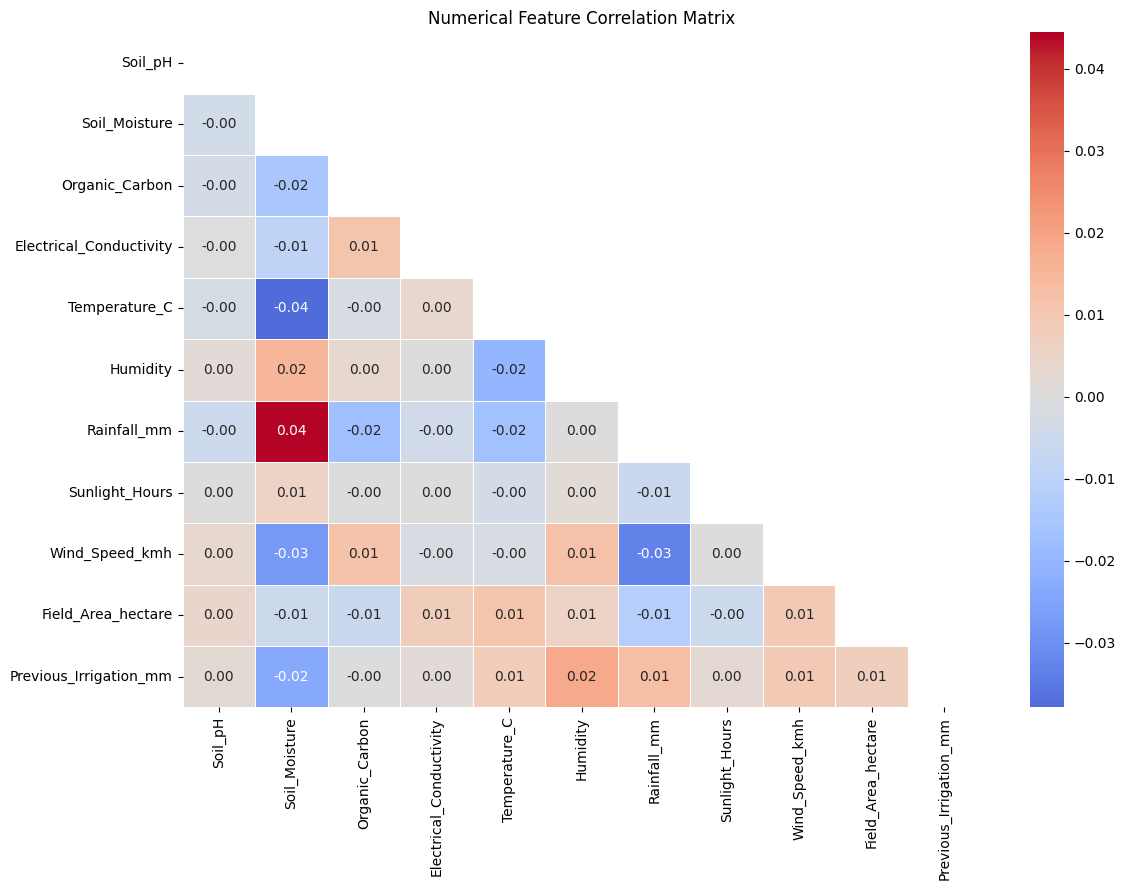

In [7]:
# Correlation Matrix
corr = train_df.select(NUM_COLS).to_pandas().corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Feature Engineering

In [8]:
NEW_COLS = [
    'heat_dryness_index', 'moisture_deficit',
    'rainfall_per_hectare', 'prev_irrigation_per_hectare', 'ph_deviation',
    'water_balance', 'vpd_proxy', 'moisture_x_rainfall',
    'sunlight_x_temp', 'ph_is_acidic', 'ph_is_alkaline',
    'area_log', 'rainfall_moisture_ratio', 'total_water_input',
    'temp_x_sunlight_humidity'
]

COMBO_COLS = ['region_crop', 'season_stage', 'crop_stage', 'soil_crop']

def add_features(df):
    area_safe = pl.col('Field_Area_hectare').clip(0.1, None)
    return df.with_columns([
        (pl.col('Temperature_C') * (100 - pl.col('Humidity'))).alias('heat_dryness_index'),
        (pl.col('Soil_Moisture') - pl.col('Rainfall_mm') / 100).alias('moisture_deficit'),
        (pl.col('Rainfall_mm') / area_safe).alias('rainfall_per_hectare'),
        (pl.col('Previous_Irrigation_mm') / area_safe).alias('prev_irrigation_per_hectare'),
        (pl.col('Soil_pH') - 6.5).abs().alias('ph_deviation'),
        (pl.col('Rainfall_mm') + pl.col('Previous_Irrigation_mm') - pl.col('Temperature_C')).alias('water_balance'),
        (pl.col('Temperature_C') / (pl.col('Humidity') + 1)).alias('vpd_proxy'),
        (pl.col('Soil_Moisture') * pl.col('Rainfall_mm')).alias('moisture_x_rainfall'),
        (pl.col('Sunlight_Hours') * pl.col('Temperature_C')).alias('sunlight_x_temp'),
        (pl.col('Soil_pH') < 6.0).cast(pl.Int8).alias('ph_is_acidic'),
        (pl.col('Soil_pH') > 7.5).cast(pl.Int8).alias('ph_is_alkaline'),
        area_safe.log().alias('area_log'),
        (pl.col('Rainfall_mm') / (pl.col('Soil_Moisture') + 1)).alias('rainfall_moisture_ratio'),
        (pl.col('Rainfall_mm') + pl.col('Previous_Irrigation_mm')).alias('total_water_input'),
        (pl.col('Temperature_C') * pl.col('Sunlight_Hours') / (pl.col('Humidity') + 1)).alias('temp_x_sunlight_humidity'),
    ])

def add_combo_features(df):
    return df.with_columns([
        (pl.col('Region') + '_' + pl.col('Crop_Type')).alias('region_crop'),
        (pl.col('Season') + '_' + pl.col('Crop_Growth_Stage')).alias('season_stage'),
        (pl.col('Crop_Type') + '_' + pl.col('Crop_Growth_Stage')).alias('crop_stage'),
        (pl.col('Soil_Type') + '_' + pl.col('Crop_Type')).alias('soil_crop'),
    ])

train_df = add_combo_features(add_features(train_df))
test_df  = add_combo_features(add_features(test_df))

print(f'Added {len(NEW_COLS)} derived + {len(COMBO_COLS)} combo features')

Added 15 derived + 4 combo features


In [9]:
# Group-stat features are computed INSIDE each CV fold (fold-safe, no OOF leak).
# Here we only define the recipe + precompute output column names; the actual
# values are built per-fold during training, using only the fold's train slice.

GROUPS = [
    ('Crop_Type',         ['Soil_Moisture', 'Previous_Irrigation_mm', 'Rainfall_mm', 'Temperature_C']),
    ('Region',            ['Rainfall_mm', 'Temperature_C', 'Humidity', 'Soil_Moisture']),
    ('Soil_Type',         ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']),
    ('Season',            ['Rainfall_mm', 'Temperature_C', 'Humidity']),
    ('Crop_Growth_Stage', ['Soil_Moisture', 'Rainfall_mm']),
]

GROUP_COLS = []
for grp_col, num_cols in GROUPS:
    for nc in num_cols:
        GROUP_COLS.extend([
            f'{grp_col}_{nc}_mean',
            f'{grp_col}_{nc}_std',
            f'{nc}_diff_{grp_col}',
        ])


def add_group_stats_from_slice(train_slice, dfs):
    """Compute group mean/std from `train_slice` only, then add mean/std/diff
    columns to each frame in `dfs` in place. Returns the list of column names added."""
    added = []
    for grp_col, num_cols in GROUPS:
        for nc in num_cols:
            agg = train_slice.groupby(grp_col)[nc].agg(['mean', 'std'])
            m, s, d = f'{grp_col}_{nc}_mean', f'{grp_col}_{nc}_std', f'{nc}_diff_{grp_col}'
            global_mean = train_slice[nc].mean()
            global_std  = train_slice[nc].std()
            for df in dfs:
                df[m] = df[grp_col].map(agg['mean']).fillna(global_mean)
                df[s] = df[grp_col].map(agg['std']).fillna(global_std)
                df[d] = df[nc] - df[m]
            added.extend([m, s, d])
    return added


print(f'Group-stat recipe defined: {len(GROUP_COLS)} features will be built per fold')

Group-stat recipe defined: 48 features will be built per fold


In [10]:
def target_encode_per_class_cv(train_pd, test_pd, cat_cols, target_col,
                                n_classes=3, n_splits=5, random_state=42, smoothing=10):
    """Per-class out-of-fold target encoding. Creates <col>_te_c{k} for each class k.
    Uses smoothed mean: (count*mean + smoothing*global) / (count + smoothing).
    Does NOT overwrite the original categorical column.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    new_cols = []
    for col in cat_cols:
        for c in range(n_classes):
            train_pd[f'{col}_te_c{c}'] = 0.0
            new_cols.append(f'{col}_te_c{c}')

        test_accum = np.zeros((len(test_pd), n_classes))

        for tr_idx, val_idx in skf.split(train_pd, train_pd[target_col]):
            tr = train_pd.iloc[tr_idx]
            for c in range(n_classes):
                is_c = (tr[target_col] == c).astype(int)
                global_p = is_c.mean()
                stats = tr.assign(_is=is_c).groupby(col)['_is'].agg(['mean', 'count'])
                smoothed = (stats['count'] * stats['mean'] + smoothing * global_p) / (stats['count'] + smoothing)

                train_pd.loc[train_pd.index[val_idx], f'{col}_te_c{c}'] = (
                    train_pd.iloc[val_idx][col].map(smoothed).fillna(global_p).values
                )
                test_accum[:, c] += test_pd[col].map(smoothed).fillna(global_p).values

        for c in range(n_classes):
            test_pd[f'{col}_te_c{c}'] = test_accum[:, c] / n_splits

    return train_pd, test_pd, new_cols

In [11]:
CAT_COLS = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region'
]

NUM_COLS = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'
]

ALL_CAT_COLS = CAT_COLS + COMBO_COLS

# Move to pandas once — encoding + TE is cleaner there
train_pd = train_df.to_pandas()
test_pd  = test_df.to_pandas()

# Ordinal target: Low < Medium < High
ORDER_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
CLASSES   = ['Low', 'Medium', 'High']
N_CLASSES = len(CLASSES)
train_pd[TARGET] = train_pd[TARGET].map(ORDER_MAP).astype(int)

# Label encode all categoricals (original + combos). Keep encoders for reference.
label_encoders = {}
for col in ALL_CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_pd[col].astype(str), test_pd[col].astype(str)])
    le.fit(combined)
    train_pd[col] = le.transform(train_pd[col].astype(str))
    test_pd[col]  = le.transform(test_pd[col].astype(str))
    label_encoders[col] = le

# Per-class target encoding proved to induce train/test drift and is always
# dropped downstream, so skip the computation entirely. Flip RUN_TE if you want
# to experiment with it again.
RUN_TE = False
if RUN_TE:
    train_pd, test_pd, TE_COLS = target_encode_per_class_cv(
        train_pd, test_pd, ALL_CAT_COLS, TARGET,
        n_classes=N_CLASSES, n_splits=5, random_state=42, smoothing=20
    )
else:
    TE_COLS = []

print(f'Classes (ordinal): {CLASSES}')
print(f'Label-encoded cats: {len(ALL_CAT_COLS)} | TE cols: {len(TE_COLS)}')

Classes (ordinal): ['Low', 'Medium', 'High']
Label-encoded cats: 12 | TE cols: 0


In [12]:
# DROP_COLS: features flagged as dead by LGB gain + all TE cols (drift-inducing).
# Note: GROUP_COLS are NOT in `train_pd` yet — they are built per-fold during
# training. The DROP_COLS entries below that refer to group-stat names are
# applied inside the fold loop after the stats are computed.
DROP_COLS = {
    # LGB importance = 0 / near 0 (from prior runs; may shift slightly after leak fix)
    'Soil_Type',
    'Season_Humidity_std', 'Season_Humidity_mean',
    'Crop_Type_Rainfall_mm_std', 'Season_Temperature_C_std',
    'Crop_Type', 'Season_Temperature_C_mean',
    'Crop_Type_Temperature_C_std', 'Crop_Growth_Stage',
    'Crop_Type_Rainfall_mm_mean', 'Crop_Type_Temperature_C_mean',
    'Region', 'ph_is_alkaline',
    'Crop_Type_Previous_Irrigation_mm_mean',
    'Crop_Type_Soil_Moisture_mean',
    # All TE columns induce train/test drift — drop wholesale
    *TE_COLS,
}

# Base features available globally (group stats appended per-fold in the CV loop).
BASE_FEATURES = [c for c in (NUM_COLS + ALL_CAT_COLS + NEW_COLS) if c not in DROP_COLS]
FEATURES      = BASE_FEATURES  # alias kept for the adversarial-validation cell

X      = train_pd[BASE_FEATURES].to_numpy()
y      = train_pd[TARGET].to_numpy()
X_test = test_pd[BASE_FEATURES].to_numpy()

CAT_IDX = [BASE_FEATURES.index(c) for c in ALL_CAT_COLS if c in BASE_FEATURES]

print(f'X shape      : {X.shape}  (base features only; group stats added per-fold)')
print(f'y shape      : {y.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'# base feats : {len(BASE_FEATURES)}')
print(f'# group feats: {len(GROUP_COLS)} (built per-fold, DROP_COLS filter applied there)')

X shape      : (630000, 33)  (base features only; group stats added per-fold)
y shape      : (630000,)
X_test shape : (270000, 33)
# base feats : 33
# group feats: 48 (built per-fold, DROP_COLS filter applied there)


# Adversarial Validation (Train vs Test Drift)

In [13]:
# Train a binary classifier: is_test = 1 if row came from test, 0 if train.
# AUC tells us how distinguishable the two sets are; feature importance tells us which
# columns carry the drift. Target (y) is NOT used here — we only use FEATURES.
from sklearn.metrics import roc_auc_score

X_adv = np.vstack([X, X_test])
y_adv = np.concatenate([np.zeros(len(X), dtype=int), np.ones(len(X_test), dtype=int)])

adv_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
adv_oof = np.zeros(len(X_adv))
adv_gain = np.zeros(len(FEATURES))

adv_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
}

print('=== Adversarial Validation ===')
for fold, (tr, va) in enumerate(adv_skf.split(X_adv, y_adv)):
    dtr = lgb.Dataset(X_adv[tr], label=y_adv[tr], categorical_feature=CAT_IDX)
    dva = lgb.Dataset(X_adv[va], label=y_adv[va], reference=dtr, categorical_feature=CAT_IDX)
    m = lgb.train(
        adv_params, dtr, num_boost_round=1000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    adv_oof[va] = m.predict(X_adv[va])
    adv_gain   += m.feature_importance(importance_type='gain') / 3

auc = roc_auc_score(y_adv, adv_oof)
print(f'\nAdversarial OOF AUC: {auc:.4f}')
if auc < 0.53:
    print('  -> No meaningful drift. LB ceiling appears structural.')
elif auc < 0.60:
    print('  -> Mild drift. Dropping top drifted features may help.')
else:
    print('  -> Significant drift. Heavy pruning recommended.')

adv_fi = pd.DataFrame({
    'feature': FEATURES,
    'adv_gain': adv_gain,
}).sort_values('adv_gain', ascending=False).reset_index(drop=True)

print('\nTop 20 features distinguishing train from test (high = drifted):')
print(adv_fi.head(20).to_string(index=False))

=== Adversarial Validation ===

Adversarial OOF AUC: 0.5017
  -> No meaningful drift. LB ceiling appears structural.

Top 20 features distinguishing train from test (high = drifted):
                    feature    adv_gain
                  soil_crop 1972.647796
                 crop_stage 1824.740517
                region_crop 1782.042087
               season_stage 1151.246341
    Electrical_Conductivity  663.017505
             Wind_Speed_kmh  600.587854
     Previous_Irrigation_mm  585.018746
                    Soil_pH  573.695829
              Temperature_C  547.648280
             Sunlight_Hours  542.706091
prev_irrigation_per_hectare  541.208987
              Soil_Moisture  509.735761
            sunlight_x_temp  507.235392
               ph_deviation  495.232726
         Field_Area_hectare  482.844259
                   Humidity  477.202178
             Organic_Carbon  472.108841
                  vpd_proxy  463.598069
       rainfall_per_hectare  459.518533
   temp_x_sunligh

# Model

In [14]:
# =============================================================================
# Fold-safe training: group stats are computed INSIDE each fold using only the
# fold's train slice (no OOF leak). Three models: LightGBM + XGBoost + CatBoost.
# =============================================================================

N_SPLITS = 5
SEED     = 42

oof_lgb  = np.zeros((len(train_pd), N_CLASSES))
test_lgb = np.zeros((len(test_pd),  N_CLASSES))
oof_xgb  = np.zeros((len(train_pd), N_CLASSES))
test_xgb = np.zeros((len(test_pd),  N_CLASSES))
oof_cb   = np.zeros((len(train_pd), N_CLASSES))
test_cb  = np.zeros((len(test_pd),  N_CLASSES))

lgb_params = {
    'objective': 'multiclass',
    'num_class': N_CLASSES,
    'metric': 'multi_logloss',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 500,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'lambda_l1': 0.5,
    'lambda_l2': 3.0,
    'min_gain_to_split': 0.02,
    'seed': SEED,
    'verbose': -1,
}

xgb_params = {
    'objective': 'multi:softprob',
    'num_class': N_CLASSES,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.03,
    'max_depth': 5,
    'min_child_weight': 20,
    'subsample': 0.7,
    'colsample_bytree': 0.6,
    'reg_alpha': 0.5,
    'reg_lambda': 3.0,
    'gamma': 1.0,
    'tree_method': 'hist',
    'seed': SEED,
    'verbosity': 0,
}

# CatBoost: higher LR + fewer iterations + tighter early-stop so it actually
# fires. Previous run (LR=0.05, iter=3000, od_wait=100) ran all 2997 iters on
# fold 1 — ~50 min/fold. These settings target ~5-10 min/fold.
cb_params = {
    'loss_function': 'MultiClass',
    'iterations': 1500,
    'learning_rate': 0.1,
    'depth': 6,
    'l2_leaf_reg': 5.0,
    'random_strength': 1.0,
    'bagging_temperature': 0.8,
    'border_count': 128,
    'random_seed': SEED,
    'verbose': 0,
    'od_type': 'Iter',
    'od_wait': 50,
    'allow_writing_files': False,
}

lgb_last_model = None
last_feat_cols = None

print('=== Fold-safe training (LGB + XGB + CatBoost) ===')
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr, va) in enumerate(skf.split(train_pd, y)):
    # 1) Fold-local frames with group stats computed from tr only
    tr_df = train_pd.iloc[tr].copy()
    va_df = train_pd.iloc[va].copy()
    te_df = test_pd.copy()

    group_cols_added = add_group_stats_from_slice(tr_df, [tr_df, va_df, te_df])
    feat_cols = [c for c in BASE_FEATURES + group_cols_added if c not in DROP_COLS]
    cat_idx   = [feat_cols.index(c) for c in ALL_CAT_COLS if c in feat_cols]
    cat_names = [c for c in ALL_CAT_COLS if c in feat_cols]

    X_tr = tr_df[feat_cols].to_numpy()
    X_va = va_df[feat_cols].to_numpy()
    X_te = te_df[feat_cols].to_numpy()
    y_tr, y_va = y[tr], y[va]

    # 2) LightGBM
    dtr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_idx)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr, categorical_feature=cat_idx)
    m_lgb = lgb.train(
        lgb_params, dtr, num_boost_round=5000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)]
    )
    oof_lgb[va] = m_lgb.predict(X_va)
    test_lgb   += m_lgb.predict(X_te) / N_SPLITS

    # 3) XGBoost
    dtr_x = xgb.DMatrix(X_tr, label=y_tr)
    dva_x = xgb.DMatrix(X_va, label=y_va)
    dte_x = xgb.DMatrix(X_te)
    m_xgb = xgb.train(
        xgb_params, dtr_x, num_boost_round=5000,
        evals=[(dva_x, 'val')], early_stopping_rounds=100, verbose_eval=0
    )
    oof_xgb[va] = m_xgb.predict(dva_x)
    test_xgb   += m_xgb.predict(dte_x) / N_SPLITS

    # 4) CatBoost — pass pandas frames so categorical dtypes stay intact
    m_cb = cb.CatBoostClassifier(**cb_params, cat_features=cat_names)
    m_cb.fit(
        tr_df[feat_cols], y_tr,
        eval_set=(va_df[feat_cols], y_va),
        use_best_model=True, verbose=0,
    )
    oof_cb[va] = m_cb.predict_proba(va_df[feat_cols])
    test_cb   += m_cb.predict_proba(te_df[feat_cols]) / N_SPLITS

    print(f'  fold={fold+1} | LGB={m_lgb.best_iteration} | XGB={m_xgb.best_iteration} | CB={m_cb.get_best_iteration()}')

    lgb_last_model = m_lgb
    last_feat_cols = feat_cols

lgb_acc = accuracy_score(y, oof_lgb.argmax(axis=1))
xgb_acc = accuracy_score(y, oof_xgb.argmax(axis=1))
cb_acc  = accuracy_score(y, oof_cb.argmax(axis=1))
print(f'\nLGB OOF Accuracy: {lgb_acc:.5f}')
print(f'XGB OOF Accuracy: {xgb_acc:.5f}')
print(f'CB  OOF Accuracy: {cb_acc:.5f}')

# Feature importance from last LGB fold (informational only)
fi = pd.DataFrame({
    'feature': last_feat_cols,
    'gain':  lgb_last_model.feature_importance(importance_type='gain'),
    'split': lgb_last_model.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False).reset_index(drop=True)

print('\nTop 20 features by gain (last LGB fold):')
print(fi.head(20).to_string(index=False))
print('\nBottom 15 features by gain (candidates to drop):')
print(fi.tail(15).to_string(index=False))

=== Fold-safe training (LGB + XGB + CatBoost) ===
  fold=1 | LGB=1101 | XGB=2455 | CB=1491


KeyboardInterrupt: 

In [ ]:
oof_list  = [oof_lgb,  oof_xgb,  oof_cb]
test_list = [test_lgb, test_xgb, test_cb]
names     = ['LGB', 'XGB', 'CB']

def blend(weights, probs_list):
    w = np.clip(np.asarray(weights, dtype=float), 0, None)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return sum(wi * p for wi, p in zip(w, probs_list))

def neg_logloss(weights, probs_list, y_true):
    blend_p = blend(weights, probs_list)
    return log_loss(y_true, np.clip(blend_p, 1e-15, 1 - 1e-15))

# Find weights that minimize OOF log-loss
res = minimize(
    neg_logloss,
    x0=np.ones(len(oof_list)) / len(oof_list),
    args=(oof_list, y),
    method='Nelder-Mead',
    options={'xatol': 1e-4, 'fatol': 1e-6, 'maxiter': 1000}
)
w_opt = np.clip(res.x, 0, None)
w_opt = w_opt / w_opt.sum()

print('Optimal weights:')
for n, w in zip(names, w_opt):
    print(f'  {n}: {w:.3f}')

oof_blend  = blend(w_opt, oof_list)
test_preds = blend(w_opt, test_list)

blend_acc = accuracy_score(y, oof_blend.argmax(axis=1))
print(f'\nBlend OOF Accuracy: {blend_acc:.5f}')
print(f'LGB: {accuracy_score(y, oof_lgb.argmax(axis=1)):.5f}')
print(f'XGB: {accuracy_score(y, oof_xgb.argmax(axis=1)):.5f}')
print(f'CB : {accuracy_score(y, oof_cb.argmax(axis=1)):.5f}')
print()
print(classification_report(y, oof_blend.argmax(axis=1), target_names=CLASSES))

# Threshold Tuning

In [ ]:
# Class-bias calibration on OOF. Adds a small per-class log-shift that is tuned
# to maximize OOF accuracy, then applies the same shift to the test predictions.
# Helps the minority class (High) where the blend argmax is conservative.

def apply_bias(probs, bias):
    logits = np.log(np.clip(probs, 1e-15, 1.0)) + bias
    logits -= logits.max(axis=1, keepdims=True)
    p = np.exp(logits)
    return p / p.sum(axis=1, keepdims=True)

def neg_acc_bias(bias, probs, y_true):
    return -(apply_bias(probs, bias).argmax(axis=1) == y_true).mean()

res = minimize(
    neg_acc_bias, x0=np.zeros(N_CLASSES),
    args=(oof_blend, y),
    method='Nelder-Mead',
    options={'xatol': 1e-4, 'fatol': 1e-6, 'maxiter': 2000}
)
bias_opt  = res.x
acc_tuned = -res.fun

oof_tuned  = apply_bias(oof_blend,  bias_opt)
test_preds = apply_bias(test_preds, bias_opt)

print(f'Pre-tune  OOF: {blend_acc:.5f}')
print(f'Post-tune OOF: {acc_tuned:.5f}  (delta {acc_tuned - blend_acc:+.5f})')
print(f'Per-class bias:  Low={bias_opt[0]:+.4f}  Medium={bias_opt[1]:+.4f}  High={bias_opt[2]:+.4f}')
print()
print(classification_report(y, oof_tuned.argmax(axis=1), target_names=CLASSES))

# Pseudo-Labeling

In [ ]:
# Pseudo-labeling — disabled by default (hurt LB in prior experiment).
# Set RUN_PL = True to try again, possibly with a tighter threshold.
RUN_PL = False
PL_THRESHOLD = 0.99

if RUN_PL:
    max_probs = test_preds.max(axis=1)
    pseudo_labels_arr = test_preds.argmax(axis=1)

    print('Test confidence distribution:')
    for thr in [0.80, 0.90, 0.95, 0.99]:
        n = (max_probs > thr).sum()
        print(f'  > {thr:.2f} : {n:>7} rows ({n / len(max_probs):.1%})')

    mask = max_probs > PL_THRESHOLD
    print(f'\nUsing threshold {PL_THRESHOLD} -> {mask.sum()} pseudo-labeled rows')

    X_pseudo = X_test[mask]
    y_pseudo = pseudo_labels_arr[mask]

    X_full = np.vstack([X, X_pseudo])
    y_full = np.concatenate([y, y_pseudo])
    pseudo_idx = np.arange(len(X), len(X) + len(X_pseudo))

    oof_lgb_pl  = np.zeros((len(X), N_CLASSES))
    test_lgb_pl = np.zeros((len(X_test), N_CLASSES))
    oof_xgb_pl  = np.zeros((len(X), N_CLASSES))
    test_xgb_pl = np.zeros((len(X_test), N_CLASSES))

    print('\n=== LightGBM (PL) ===')
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=LGB_SEED)
    for fold, (tr, va) in enumerate(skf.split(X, y)):
        tr_aug = np.concatenate([tr, pseudo_idx])
        dtr = lgb.Dataset(X_full[tr_aug], label=y_full[tr_aug], categorical_feature=CAT_IDX)
        dva = lgb.Dataset(X[va], label=y[va], reference=dtr, categorical_feature=CAT_IDX)
        model = lgb.train(
            lgb_params, dtr, num_boost_round=5000,
            valid_sets=[dva],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)]
        )
        oof_lgb_pl[va] = model.predict(X[va])
        test_lgb_pl  += model.predict(X_test) / N_SPLITS
        print(f'  fold={fold+1} best_iter={model.best_iteration}')
    print(f'LGB+PL OOF: {accuracy_score(y, oof_lgb_pl.argmax(axis=1)):.5f}')

    print('\n=== XGBoost (PL) ===')
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=XGB_SEED)
    for fold, (tr, va) in enumerate(skf.split(X, y)):
        tr_aug = np.concatenate([tr, pseudo_idx])
        dtr = xgb.DMatrix(X_full[tr_aug], label=y_full[tr_aug])
        dva = xgb.DMatrix(X[va], label=y[va])
        dte = xgb.DMatrix(X_test)
        model = xgb.train(
            xgb_params, dtr, num_boost_round=5000,
            evals=[(dva, 'val')],
            early_stopping_rounds=100, verbose_eval=0
        )
        oof_xgb_pl[va] = model.predict(dva)
        test_xgb_pl  += model.predict(dte) / N_SPLITS
        print(f'  fold={fold+1} best_iter={model.best_iteration}')
    print(f'XGB+PL OOF: {accuracy_score(y, oof_xgb_pl.argmax(axis=1)):.5f}')

    oof_list_pl  = [oof_lgb_pl,  oof_xgb_pl]
    test_list_pl = [test_lgb_pl, test_xgb_pl]

    res = minimize(
        neg_logloss, x0=np.ones(len(oof_list_pl)) / len(oof_list_pl),
        args=(oof_list_pl, y), method='Nelder-Mead',
        options={'xatol': 1e-4, 'fatol': 1e-6, 'maxiter': 500}
    )
    w_pl = np.clip(res.x, 0, None); w_pl = w_pl / w_pl.sum()
    oof_blend_pl = blend(w_pl, oof_list_pl)
    test_preds   = blend(w_pl, test_list_pl)

    blend_acc_pl = accuracy_score(y, oof_blend_pl.argmax(axis=1))
    print(f'\nBlend OOF (pre-PL):  {blend_acc:.5f}')
    print(f'Blend OOF (post-PL): {blend_acc_pl:.5f}  (delta {blend_acc_pl - blend_acc:+.5f})')
    print()
    print(classification_report(y, oof_blend_pl.argmax(axis=1), target_names=CLASSES))
else:
    print('Pseudo-labeling skipped (RUN_PL=False). Using pre-PL test_preds.')

In [ ]:
pred_labels = [CLASSES[i] for i in test_preds.argmax(axis=1)]

submission = pl.DataFrame({
    'id': test_pd['id'].to_numpy(),
    TARGET: pred_labels,
})

submission.write_csv('submission.csv')
print(submission.head())
print('\nPrediction distribution:')
print(pd.Series(pred_labels).value_counts())

shape: (5, 2)
┌────────┬─────────────────┐
│ id     ┆ Irrigation_Need │
│ ---    ┆ ---             │
│ i64    ┆ str             │
╞════════╪═════════════════╡
│ 630000 ┆ Low             │
│ 630001 ┆ Low             │
│ 630002 ┆ Low             │
│ 630003 ┆ Low             │
│ 630004 ┆ Low             │
└────────┴─────────────────┘

Prediction distribution:
Low       159881
Medium    101566
High        8553
Name: count, dtype: int64
